# Belief-State Geometry — RRXOR: distributed across layers, and beyond the next token

The second result from [arXiv:2405.15943](https://arxiv.org/abs/2405.15943). **RRXOR** ('Random, Random, XOR') emits two fair bits then their XOR. Two things differ from Mess3:

1. **The belief geometry is distributed across layers** — recovery from the *concatenation* of all layers' residuals beats any single layer.
2. **The belief carries information about the whole future**, beyond the next token the model was trained on — the residual stream encodes belief that the next-token distribution (a many-to-one function of belief) cannot reconstruct.

In [1]:
# Make src/ importable and use inline figures.
import sys; sys.path.insert(0, "../src")
%matplotlib inline
import numpy as np
from pathlib import Path


## 1. Train (or load) the RRXOR model

In [2]:
from hmms import RRXOR
from train import train, TrainConfig, save_checkpoint

# The committed checkpoint loads instantly. Delete it (or run the CLI with
# --steps 50000) to retrain from scratch; RRXOR needs more steps than Mess3
# to crystallise its (distributed) belief representation.
ckpt_path = Path('../checkpoints/rrxor_fast.pt')
if not ckpt_path.exists():
    res = train(RRXOR(), train_cfg=TrainConfig.fast(n_steps=50000, device='cpu'),
                process_name='rrxor')
    save_checkpoint(res, ckpt_path)
else:
    print('Using existing checkpoint:', ckpt_path)

Using existing checkpoint: ../checkpoints/rrxor_fast.pt


## 2. Probe per layer, across layers, and run the future-information analysis

Moving model to device:  mps


R² per layer       : {'0': 0.401, '1': 0.473, '2': 0.554, '3': 0.613}
R² concat layers   : 0.8169
concat beats single: True


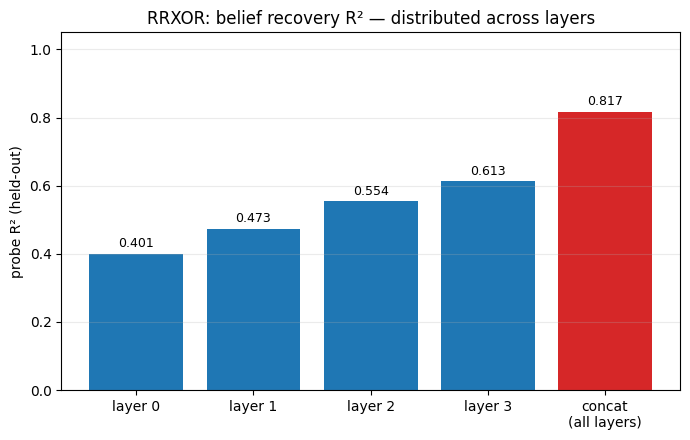

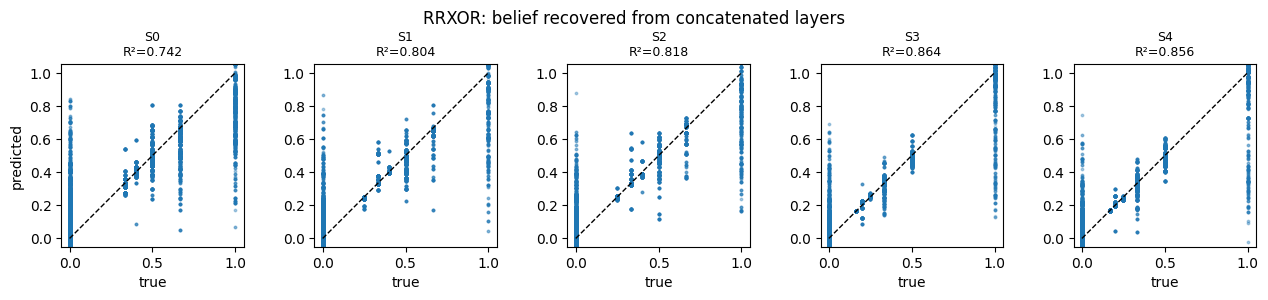

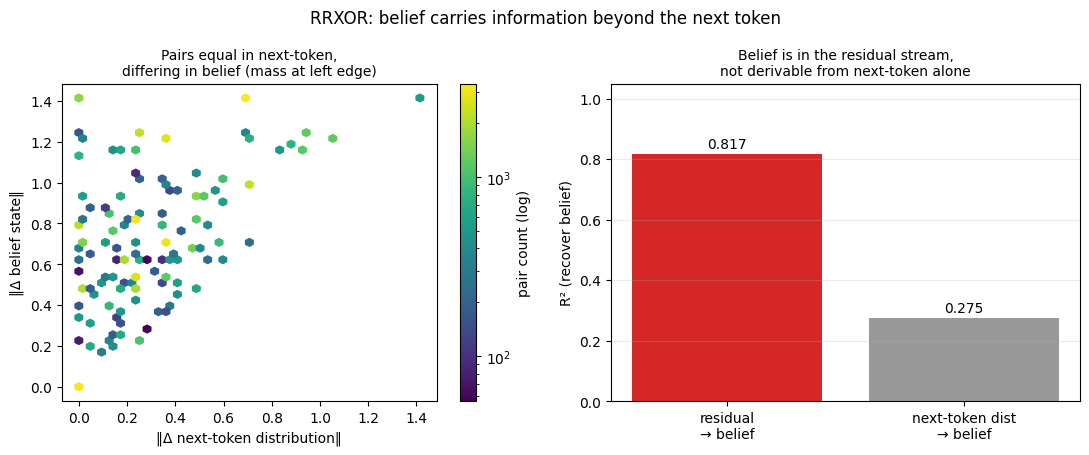

In [3]:
from experiments import run_rrxor_experiment
out = run_rrxor_experiment('../checkpoints/rrxor_fast.pt', save=True)
m = out['metrics']
print('R² per layer       :', {k: round(v,3) for k,v in m['probe']['r2_per_layer'].items()})
print('R² concat layers   :', round(m['probe']['r2_concat_all_layers'], 4))
print('concat beats single:', m['probe']['concat_beats_best_single_layer'])

## 3. The representation is distributed across layers
The concatenation across layers (red) recovers the belief better than any single layer — the geometry is not localised to the final residual stream.

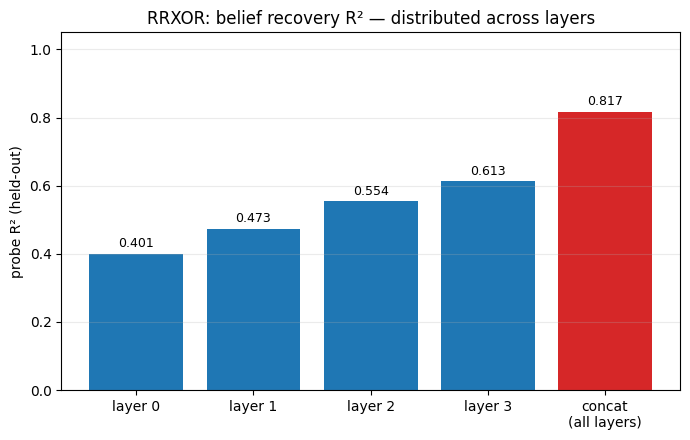

In [4]:
out['figures']['layer_r2']

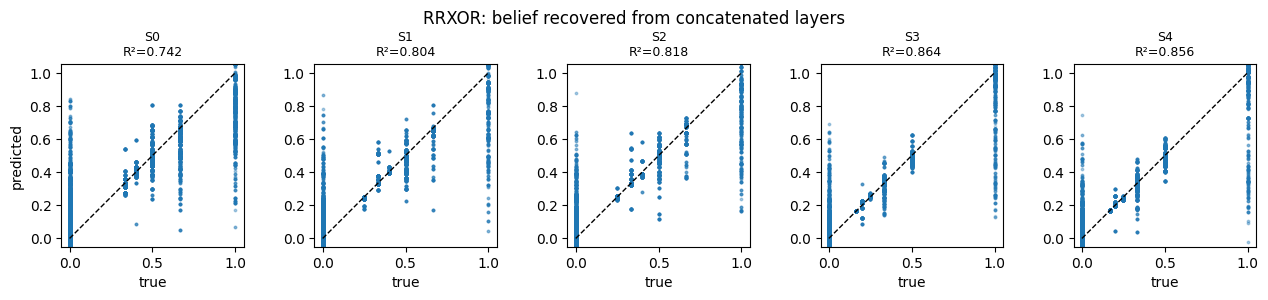

In [5]:
out['figures']['pred_vs_true']

## 4. The belief carries information beyond the next token
**Left:** pairs of positions with nearly equal next-token distributions can still have very different beliefs (mass at the left edge) — the belief distinguishes futures the next token cannot. **Right:** the residual stream recovers the belief (high R²) far better than the next-token distribution can (the next-token distribution is a lossy function of the belief).

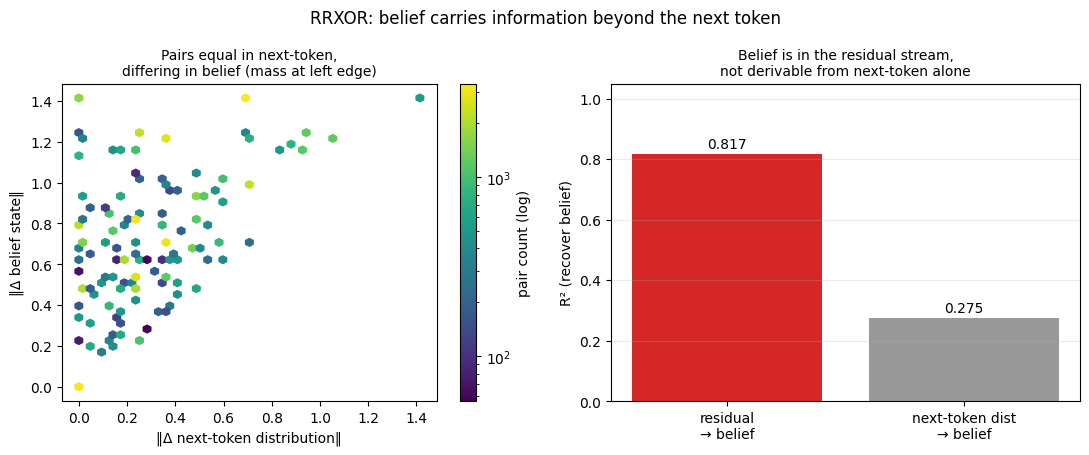

In [6]:
out['figures']['future_information']

In [7]:
print('R² residual → belief        :', round(m['future_information']['r2_residual_to_belief'], 4))
print('R² next-token dist → belief :', round(m['future_information']['r2_nexttoken_dist_to_belief'], 4))

R² residual → belief        : 0.8169
R² next-token dist → belief : 0.2748
